
# RAG Retrieval Evaluation — Precision@k, Recall@k & MRR

This notebook is a complete, programmatic evaluation framework for the **retrieval component** of a Retrieval-Augmented Generation (RAG) pipeline.

## Objectives

- Explain why retrieval quality controls downstream RAG accuracy and reliability.
- Define and calculate **Precision@k**, **Recall@k**, and **Mean Reciprocal Rank (MRR)**.
- Build a **ground-truth evaluation dataset** mapping questions to relevant source chunks.
- Run a repeatable retrieval evaluation loop.
- Compare **chunking strategies** and **embedding/retrieval models**.
- Produce tables and plots that can be used directly in an evaluation report.
- Provide concrete optimization recommendations based on measured results.

> **Important:** The included corpus is a small synthetic demonstration corpus so the notebook runs immediately. Replace the corpus and ground-truth labels with your own RAG documents for a production evaluation.



## 1. Retrieval metrics

Let:

- \(q\) = a query
- \(R_q\) = set of ground-truth relevant chunks for query \(q\)
- \(Retrieved_k(q)\) = the top-\(k\) chunks returned by the retriever

### Precision@k

\[
Precision@k = \frac{|Retrieved_k(q) \cap R_q|}{k}
\]

**Meaning:** Of the top \(k\) chunks we retrieved, what fraction are relevant?

High Precision@k means the LLM receives little irrelevant context.

### Recall@k

\[
Recall@k = \frac{|Retrieved_k(q) \cap R_q|}{|R_q|}
\]

**Meaning:** Of all known relevant chunks, what fraction did we successfully retrieve?

High Recall@k means the retriever is less likely to miss information needed to answer the question.

### Precision vs Recall

- **Precision@k** penalizes irrelevant retrieved chunks.
- **Recall@k** penalizes relevant chunks that were missed.
- A RAG system often needs a balance: high recall prevents missing evidence, while high precision prevents context pollution.

### Mean Reciprocal Rank (MRR)

For each query:

\[
RR_q = \frac{1}{rank_q}
\]

where \(rank_q\) is the rank of the **first relevant result**. If no relevant result appears in the evaluated top-k list, the reciprocal rank is 0.

Then:

\[
MRR = \frac{1}{|Q|}\sum_{q \in Q} RR_q
\]

MRR is especially useful when getting **one highly relevant chunk near the top** is important.


In [1]:

# 2. Imports and reproducibility

from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)
print("Environment ready.")


Environment ready.



## 3. Evaluation corpus

The demonstration corpus contains documents about:

- retrieval quality
- chunking
- embedding models
- vector databases
- RAG evaluation
- unrelated material

In a real project, replace this table with your source documents and stable document IDs.


In [2]:

documents = [
    {
        "doc_id": "doc_retrieval",
        "title": "Retrieval Quality in RAG",
        "text": (
            "Retrieval quality is a critical component of a RAG system. "
            "If the retriever fails to return the evidence required by a question, "
            "the language model may generate an incomplete or unsupported answer. "
            "Retrieval should therefore be evaluated independently before evaluating generation."
        ),
    },
    {
        "doc_id": "doc_chunking",
        "title": "Chunking Strategies",
        "text": (
            "Chunking divides source documents into retrievable units. "
            "Fixed-size chunking is simple and predictable, while sentence-aware and semantic chunking "
            "can preserve meaning more effectively. Very small chunks may lose context, while very large "
            "chunks can reduce retrieval precision and introduce irrelevant information."
        ),
    },
    {
        "doc_id": "doc_embeddings",
        "title": "Embedding Models",
        "text": (
            "Embedding models transform text into dense numerical vectors. "
            "A good embedding model places semantically similar questions and passages close together. "
            "Different embedding models can produce substantially different retrieval results, so they "
            "should be compared on the same evaluation set."
        ),
    },
    {
        "doc_id": "doc_vector_db",
        "title": "Vector Database Search",
        "text": (
            "A vector database indexes embeddings and supports nearest-neighbor search. "
            "Typical retrieval uses a query embedding, similarity scoring, and top-k selection. "
            "Evaluation should use the same search configuration that the production RAG pipeline uses."
        ),
    },
    {
        "doc_id": "doc_evaluation",
        "title": "RAG Evaluation",
        "text": (
            "RAG retrieval evaluation uses a labeled dataset of questions and relevant context. "
            "Precision@k measures the proportion of retrieved results that are relevant. "
            "Recall@k measures the proportion of relevant contexts that were retrieved. "
            "MRR measures how high the first relevant result appears in the ranking."
        ),
    },
    {
        "doc_id": "doc_irrelevant",
        "title": "Project Management Notes",
        "text": (
            "Project planning should include milestones, owners, delivery dates, risks, and review meetings. "
            "A project dashboard can be used to monitor progress and communicate status."
        ),
    },
]

docs_df = pd.DataFrame(documents)
docs_df


,doc_id,title,text
0,doc_retrieval,Retrieval Quality in RAG,Retrieval quality is a critical component of a RAG system. If the retriever fails to return the evidence required by...
1,doc_chunking,Chunking Strategies,"Chunking divides source documents into retrievable units. Fixed-size chunking is simple and predictable, while sente..."
2,doc_embeddings,Embedding Models,Embedding models transform text into dense numerical vectors. A good embedding model places semantically similar que...
3,doc_vector_db,Vector Database Search,"A vector database indexes embeddings and supports nearest-neighbor search. Typical retrieval uses a query embedding,..."
4,doc_evaluation,RAG Evaluation,RAG retrieval evaluation uses a labeled dataset of questions and relevant context. Precision@k measures the proporti...
5,doc_irrelevant,Project Management Notes,"Project planning should include milestones, owners, delivery dates, risks, and review meetings. A project dashboard ..."



## 4. Ground-truth evaluation dataset

A useful ground-truth row contains:

- a unique query ID
- the user question
- one or more **known relevant source chunks/document IDs**
- optionally, a relevance grade

For retrieval metrics in this notebook, relevance is binary: a chunk is either relevant or not relevant.

In a production evaluation, ground truth should ideally be created by domain experts or by a carefully reviewed annotation process. Multiple relevant chunks should be labeled when a question genuinely requires evidence from multiple places.


In [3]:

ground_truth = pd.DataFrame([
    {
        "query_id": "q1",
        "question": "Why is retrieval quality important in RAG?",
        "relevant_doc_ids": ["doc_retrieval"],
    },
    {
        "query_id": "q2",
        "question": "What are the disadvantages of very small and very large chunks?",
        "relevant_doc_ids": ["doc_chunking"],
    },
    {
        "query_id": "q3",
        "question": "How do embedding models affect retrieval?",
        "relevant_doc_ids": ["doc_embeddings"],
    },
    {
        "query_id": "q4",
        "question": "How does a vector database retrieve the top-k results?",
        "relevant_doc_ids": ["doc_vector_db"],
    },
    {
        "query_id": "q5",
        "question": "What is the difference between Precision@k and Recall@k?",
        "relevant_doc_ids": ["doc_evaluation"],
    },
    {
        "query_id": "q6",
        "question": "How can retrieval be evaluated before generation?",
        "relevant_doc_ids": ["doc_retrieval", "doc_evaluation"],
    },
    {
        "query_id": "q7",
        "question": "Which chunking approach can preserve meaning better than fixed-size chunks?",
        "relevant_doc_ids": ["doc_chunking"],
    },
    {
        "query_id": "q8",
        "question": "Why should the production search configuration be used during evaluation?",
        "relevant_doc_ids": ["doc_vector_db"],
    },
])

ground_truth


,query_id,question,relevant_doc_ids
0,q1,Why is retrieval quality important in RAG?,[doc_retrieval]
1,q2,What are the disadvantages of very small and very large chunks?,[doc_chunking]
2,q3,How do embedding models affect retrieval?,[doc_embeddings]
3,q4,How does a vector database retrieve the top-k results?,[doc_vector_db]
4,q5,What is the difference between Precision@k and Recall@k?,[doc_evaluation]
5,q6,How can retrieval be evaluated before generation?,"[doc_retrieval, doc_evaluation]"
6,q7,Which chunking approach can preserve meaning better than fixed-size chunks?,[doc_chunking]
7,q8,Why should the production search configuration be used during evaluation?,[doc_vector_db]



### Ground-truth quality checklist

Before trusting your benchmark:

1. Every query should have at least one relevant chunk.
2. Relevant chunks should be stable IDs, not fragile row numbers.
3. Include queries that require multiple chunks.
4. Include paraphrased questions rather than only copying source wording.
5. Include difficult queries and near-duplicate distractors.
6. Keep the evaluation set fixed while comparing retrievers.
7. Add new held-out queries periodically to detect overfitting.



## 5. Chunking strategies

We compare three simple strategies:

1. **Document-level:** one chunk per document.
2. **Fixed-size:** split each document into word windows.
3. **Sentence-aware:** split on sentence boundaries and group nearby sentences.

In real RAG systems, you can replace these functions with your production chunker and evaluate exactly the same way.


In [4]:

def split_sentences(text):
    # Simple demo sentence splitter. Production systems can use spaCy, NLTK,
    # a tokenizer-aware splitter, or a framework's sentence splitter.
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def chunk_document_level(documents):
    rows = []
    for d in documents:
        rows.append({
            "chunk_id": d["doc_id"] + "_c0",
            "doc_id": d["doc_id"],
            "title": d["title"],
            "text": d["text"],
            "chunk_strategy": "document",
        })
    return pd.DataFrame(rows)


def chunk_fixed_words(documents, chunk_size=35, overlap=8):
    rows = []
    for d in documents:
        words = d["text"].split()
        start = 0
        chunk_num = 0
        while start < len(words):
            end = min(start + chunk_size, len(words))
            text = " ".join(words[start:end])
            rows.append({
                "chunk_id": f'{d["doc_id"]}_c{chunk_num}',
                "doc_id": d["doc_id"],
                "title": d["title"],
                "text": text,
                "chunk_strategy": f"fixed_{chunk_size}_overlap_{overlap}",
            })
            if end == len(words):
                break
            start = max(end - overlap, start + 1)
            chunk_num += 1
    return pd.DataFrame(rows)


def chunk_sentence_aware(documents, sentences_per_chunk=2):
    rows = []
    for d in documents:
        sentences = split_sentences(d["text"])
        for i in range(0, len(sentences), sentences_per_chunk):
            text = " ".join(sentences[i:i+sentences_per_chunk])
            rows.append({
                "chunk_id": f'{d["doc_id"]}_c{i // sentences_per_chunk}',
                "doc_id": d["doc_id"],
                "title": d["title"],
                "text": text,
                "chunk_strategy": f"sentence_{sentences_per_chunk}",
            })
    return pd.DataFrame(rows)


chunkers = {
    "document": chunk_document_level,
    "fixed": lambda ds: chunk_fixed_words(ds, chunk_size=35, overlap=8),
    "sentence": lambda ds: chunk_sentence_aware(ds, sentences_per_chunk=2),
}

chunk_sets = {name: fn(documents) for name, fn in chunkers.items()}

for name, chunks in chunk_sets.items():
    print(f"{name:10s}: {len(chunks)} chunks")


document  : 6 chunks
fixed     : 10 chunks
sentence  : 11 chunks



## 6. Retriever implementations

The notebook uses cosine similarity for retrieval.

### Baseline: TF-IDF

TF-IDF is lexical rather than semantic, but it is valuable as a reproducible baseline.

### Optional dense embeddings

If `sentence-transformers` is installed and an embedding model is available, the notebook can compare dense semantic retrieval too.

Recommended examples for a real benchmark include models from the BGE, E5, or Sentence-Transformers families. Use the same query set, chunk set, and top-k values when comparing models.


In [5]:

class TfidfRetriever:
    def __init__(self, chunks):
        self.chunks = chunks.reset_index(drop=True).copy()
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True,
        )
        self.matrix = self.vectorizer.fit_transform(self.chunks["text"])

    def search(self, query, k=5):
        q_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(q_vec, self.matrix).ravel()
        order = np.argsort(-scores)[:k]
        result = self.chunks.iloc[order].copy()
        result["score"] = scores[order]
        return result.reset_index(drop=True)


class SentenceTransformerRetriever:
    def __init__(self, chunks, model_name="all-MiniLM-L6-v2"):
        try:
            from sentence_transformers import SentenceTransformer
        except ImportError as e:
            raise ImportError(
                "Install sentence-transformers first: pip install sentence-transformers"
            ) from e

        self.chunks = chunks.reset_index(drop=True).copy()
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)
        self.matrix = self.model.encode(
            self.chunks["text"].tolist(),
            normalize_embeddings=True,
            show_progress_bar=False,
        )

    def search(self, query, k=5):
        q_vec = self.model.encode(
            [query],
            normalize_embeddings=True,
            show_progress_bar=False,
        )
        scores = np.asarray(q_vec @ self.matrix.T).ravel()
        order = np.argsort(-scores)[:k]
        result = self.chunks.iloc[order].copy()
        result["score"] = scores[order]
        return result.reset_index(drop=True)



## 7. Evaluation functions

The key design choice is that **ground truth is compared using `doc_id`**, not chunk position. This means a relevant chunk remains relevant even when a different chunking strategy creates different chunk IDs.

For chunk-level ground truth in a real project, change the relevance mapping to stable chunk IDs or use a parent-document relevance policy explicitly.


In [6]:

def relevance_by_doc_id(retrieved_df, relevant_doc_ids):
    return [doc_id in set(relevant_doc_ids) for doc_id in retrieved_df["doc_id"]]


def precision_at_k(retrieved_df, relevant_doc_ids, k):
    top = retrieved_df.head(k)
    if k == 0:
        return 0.0
    hits = sum(relevance_by_doc_id(top, relevant_doc_ids))
    return hits / k


def recall_at_k(retrieved_df, relevant_doc_ids, k):
    relevant_doc_ids = set(relevant_doc_ids)
    if not relevant_doc_ids:
        return 0.0
    top = retrieved_df.head(k)
    hits = sum(doc_id in relevant_doc_ids for doc_id in top["doc_id"])
    return hits / len(relevant_doc_ids)


def reciprocal_rank(retrieved_df, relevant_doc_ids, k=None):
    relevant_doc_ids = set(relevant_doc_ids)
    top = retrieved_df if k is None else retrieved_df.head(k)
    for rank, doc_id in enumerate(top["doc_id"], start=1):
        if doc_id in relevant_doc_ids:
            return 1.0 / rank
    return 0.0


def evaluate_retriever(retriever, ground_truth, ks=(1, 3, 5)):
    rows = []
    max_k = max(ks)

    for _, q in ground_truth.iterrows():
        retrieved = retriever.search(q["question"], k=max_k)

        row = {
            "query_id": q["query_id"],
            "question": q["question"],
            "relevant_doc_ids": q["relevant_doc_ids"],
            "MRR@{}".format(max_k): reciprocal_rank(
                retrieved, q["relevant_doc_ids"], k=max_k
            ),
        }

        for k in ks:
            row[f"Precision@{k}"] = precision_at_k(
                retrieved, q["relevant_doc_ids"], k
            )
            row[f"Recall@{k}"] = recall_at_k(
                retrieved, q["relevant_doc_ids"], k
            )

        row["top_result"] = retrieved.iloc[0]["doc_id"] if len(retrieved) else None
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_evaluation(per_query_df, label):
    metric_cols = [
        c for c in per_query_df.columns
        if c.startswith("Precision@") or c.startswith("Recall@") or c.startswith("MRR@")
    ]
    summary = per_query_df[metric_cols].mean().to_dict()
    summary["configuration"] = label
    return pd.Series(summary)


print("Metric functions ready.")


Metric functions ready.



## 8. Run the baseline benchmark

This evaluates TF-IDF retrieval under each chunking strategy.

The benchmark is deliberately identical across strategies:

- same questions
- same ground truth
- same top-k values
- same evaluation formulas

That makes differences attributable to the retrieval configuration rather than changes in the test set.


In [7]:

KS = (1, 3, 5)

all_results = []
per_query_results = {}

for chunk_name, chunks in chunk_sets.items():
    retriever = TfidfRetriever(chunks)
    result = evaluate_retriever(retriever, ground_truth, ks=KS)
    label = f"TF-IDF + {chunk_name} chunks"

    per_query_results[label] = result
    summary = summarize_evaluation(result, label)
    all_results.append(summary)

baseline_summary = pd.DataFrame(all_results).set_index("configuration")
baseline_summary


,MRR@5,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5
configuration,,,,,,,
TF-IDF + document chunks,0.9375,0.875,0.8125,0.333333,0.9375,0.225,1.000
TF-IDF + fixed chunks,0.9375,0.875,0.8125,0.416667,1.1875,0.300,1.375
TF-IDF + sentence chunks,0.9375,0.875,0.8125,0.500000,1.3750,0.325,1.500



## 9. Inspect query-level failures

Aggregate scores tell us **how much** performance changes. Query-level results tell us **why**.

Look for:

- queries with Recall@5 = 0
- low MRR
- a relevant document appearing only at rank 4–5
- a repeated distractor document occupying the top ranks


In [8]:

# Show the weakest cases for the document-level TF-IDF baseline.
baseline_label = "TF-IDF + document chunks"
baseline_queries = per_query_results[baseline_label].copy()

baseline_queries[
    ["query_id", "question", "Precision@3", "Recall@3", "MRR@5", "top_result"]
].sort_values(["Recall@3", "MRR@5"]).head(10)


,query_id,question,Precision@3,Recall@3,MRR@5,top_result
5,q6,How can retrieval be evaluated before generation?,0.333333,0.5,1.0,doc_retrieval
4,q5,What is the difference between Precision@k and Recall@k?,0.333333,1.0,0.5,doc_chunking
0,q1,Why is retrieval quality important in RAG?,0.333333,1.0,1.0,doc_retrieval
1,q2,What are the disadvantages of very small and very large chunks?,0.333333,1.0,1.0,doc_chunking
2,q3,How do embedding models affect retrieval?,0.333333,1.0,1.0,doc_embeddings
3,q4,How does a vector database retrieve the top-k results?,0.333333,1.0,1.0,doc_vector_db
6,q7,Which chunking approach can preserve meaning better than fixed-size chunks?,0.333333,1.0,1.0,doc_chunking
7,q8,Why should the production search configuration be used during evaluation?,0.333333,1.0,1.0,doc_vector_db



## 10. Compare chunking strategies visually

For this experiment, compare Precision@k and Recall@k across the three chunking strategies.

### Interpretation

- If smaller chunks increase Recall but reduce Precision, they may retrieve more evidence while also introducing more noise.
- If sentence-aware chunks improve both, they may provide a better semantic unit for the corpus.
- If document-level chunks have high recall but poor precision, the LLM is receiving too much irrelevant text per retrieved item.


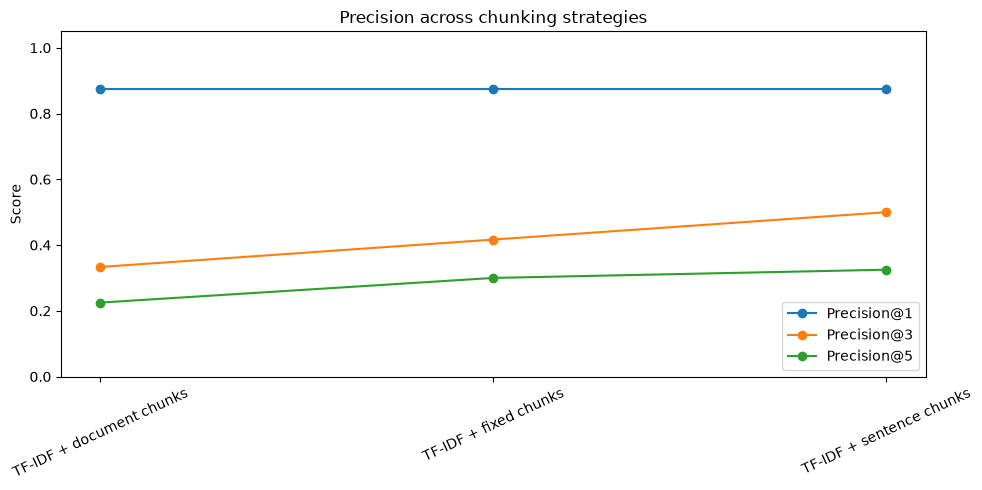

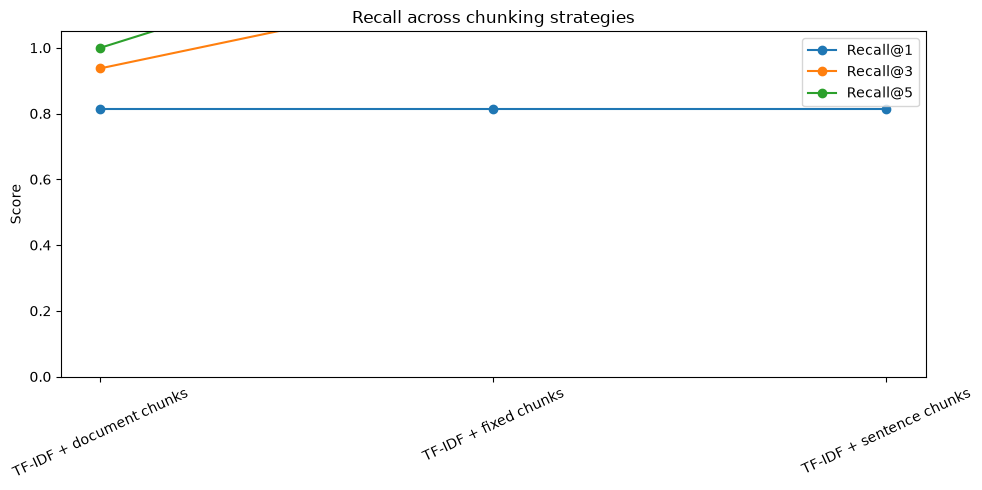

In [9]:

plot_df = baseline_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["Precision@1", "Precision@3", "Precision@5"]:
    ax.plot(plot_df["configuration"], plot_df[metric], marker="o", label=metric)
ax.set_title("Precision across chunking strategies")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["Recall@1", "Recall@3", "Recall@5"]:
    ax.plot(plot_df["configuration"], plot_df[metric], marker="o", label=metric)
ax.set_title("Recall across chunking strategies")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()



## 11. Compare embedding/retrieval models

The following cell attempts to load a dense Sentence-Transformers model.

If the package/model is unavailable, the notebook continues and reports the installation command rather than failing the whole evaluation.

For a serious benchmark, compare at least:

- your current production embedding model
- one stronger semantic embedding model
- optionally, a lexical/hybrid baseline

Keep the vector database/search settings controlled while changing the embedding model.


In [10]:

DENSE_MODELS = [
    "all-MiniLM-L6-v2",
    # Add another model here for a real comparison, for example:
    # "BAAI/bge-small-en-v1.5",
]

dense_summaries = []
dense_per_query = {}

try:
    import sentence_transformers  # noqa: F401
    dense_available = True
except ImportError:
    dense_available = False
    print(
        "Dense evaluation skipped because sentence-transformers is not installed.\n"
        "Install with: pip install sentence-transformers"
    )

if dense_available:
    # Use sentence-aware chunks for the dense-model comparison.
    dense_chunks = chunk_sets["sentence"]

    for model_name in DENSE_MODELS:
        try:
            retriever = SentenceTransformerRetriever(
                dense_chunks,
                model_name=model_name
            )
            result = evaluate_retriever(retriever, ground_truth, ks=KS)
            label = f"{model_name} + sentence chunks"
            dense_per_query[label] = result
            dense_summaries.append(summarize_evaluation(result, label))
            print(f"Completed: {label}")
        except Exception as exc:
            print(f"Could not evaluate {model_name}: {exc}")

dense_summary = (
    pd.DataFrame(dense_summaries).set_index("configuration")
    if dense_summaries else pd.DataFrame()
)
dense_summary


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5571.35it/s]


Completed: all-MiniLM-L6-v2 + sentence chunks


,MRR@5,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5
configuration,,,,,,,
all-MiniLM-L6-v2 + sentence chunks,1.0,1.0,0.9375,0.583333,1.5625,0.4,1.75



## 12. Combined results

This table combines the baseline chunking experiment and any dense embedding experiments that successfully ran.


In [11]:

combined_summary = pd.concat(
    [baseline_summary, dense_summary],
    axis=0,
    sort=False
)

combined_summary.sort_values(
    by="Recall@5",
    ascending=False
)


,MRR@5,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5
configuration,,,,,,,
all-MiniLM-L6-v2 + sentence chunks,1.0000,1.000,0.9375,0.583333,1.5625,0.400,1.750
TF-IDF + sentence chunks,0.9375,0.875,0.8125,0.500000,1.3750,0.325,1.500
TF-IDF + fixed chunks,0.9375,0.875,0.8125,0.416667,1.1875,0.300,1.375
TF-IDF + document chunks,0.9375,0.875,0.8125,0.333333,0.9375,0.225,1.000



## 13. Automated optimization recommendations

The following rule-based analysis converts measured retrieval behavior into concrete next steps.

These are heuristics rather than universal laws. The point is to turn benchmark data into an actionable experiment backlog.


In [12]:

def generate_recommendations(summary_df):
    recommendations = []

    if summary_df.empty:
        return ["Run at least one retriever configuration before generating recommendations."]

    best_recall = summary_df["Recall@5"].idxmax()
    best_precision = summary_df["Precision@3"].idxmax()
    best_mrr = summary_df["MRR@5"].idxmax()

    recommendations.append(
        f"Best Recall@5: {best_recall} ({summary_df.loc[best_recall, 'Recall@5']:.3f}). "
        "Use this configuration as the recall-oriented candidate."
    )
    recommendations.append(
        f"Best Precision@3: {best_precision} ({summary_df.loc[best_precision, 'Precision@3']:.3f}). "
        "Use this configuration when context noise is the primary concern."
    )
    recommendations.append(
        f"Best MRR@5: {best_mrr} ({summary_df.loc[best_mrr, 'MRR@5']:.3f}). "
        "This configuration ranks the first relevant result highest on average."
    )

    precision_recall_gap = (
        summary_df["Recall@5"] - summary_df["Precision@5"]
    )
    if precision_recall_gap.max() > 0.35:
        recommendations.append(
            "There is a substantial recall/precision trade-off. Test smaller top-k values, "
            "reranking, metadata filtering, or hybrid lexical+dense retrieval."
        )

    if summary_df["Recall@5"].max() < 0.75:
        recommendations.append(
            "Recall@5 is below 0.75 for every configuration. Improve semantic coverage first: "
            "review chunk boundaries, overlap, query rewriting, and embedding quality."
        )

    if summary_df["MRR@5"].max() < 0.60:
        recommendations.append(
            "MRR@5 is relatively low. Investigate ranking quality and consider a cross-encoder "
            "or LLM reranker after candidate retrieval."
        )

    return recommendations


recommendations = generate_recommendations(combined_summary)
for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")


1. Best Recall@5: all-MiniLM-L6-v2 + sentence chunks (1.750). Use this configuration as the recall-oriented candidate.
2. Best Precision@3: all-MiniLM-L6-v2 + sentence chunks (0.583). Use this configuration when context noise is the primary concern.
3. Best MRR@5: all-MiniLM-L6-v2 + sentence chunks (1.000). This configuration ranks the first relevant result highest on average.
4. There is a substantial recall/precision trade-off. Test smaller top-k values, reranking, metadata filtering, or hybrid lexical+dense retrieval.



# 14. Evaluation Report

## Executive summary

Retrieval is the first quality gate in a RAG pipeline. If the correct evidence is absent from the retrieved context, the generator cannot reliably recover it. Therefore, retrieval should be benchmarked independently using a fixed, labeled evaluation set before optimizing the generation model.

This notebook evaluates retrieval using:

- **Precision@k** — relevance density of the top-k results.
- **Recall@k** — coverage of known relevant evidence.
- **MRR** — how highly the first relevant result is ranked.

## Ground-truth methodology

Each evaluation query is linked to one or more known relevant document IDs. This provides a deterministic reference against which retrieval results can be scored. For a production benchmark, ground truth should be reviewed by domain experts and expanded with difficult, paraphrased, multi-hop, and multi-document questions.

## What to report

Use the `combined_summary` table above as the primary quantitative result. Report at minimum:

| Configuration | Precision@3 | Recall@3 | Precision@5 | Recall@5 | MRR@5 |
|---|---:|---:|---:|---:|---:|
| Each evaluated configuration | generated above | generated above | generated above | generated above | generated above |

## Chunking analysis

Compare the three chunking configurations using the same evaluation questions.

- Prefer the configuration with stronger Recall when missing evidence is the main failure mode.
- Prefer stronger Precision when the LLM context window is constrained or irrelevant context is causing answer degradation.
- Prefer a balanced configuration when both metrics are important.
- Inspect query-level failures before declaring a winner; aggregate averages can hide specific high-impact failures.

## Embedding-model analysis

Embedding models should be compared on exactly the same ground-truth queries and chunks. A stronger semantic model should improve retrieval of paraphrases and conceptually related text, but model choice should be validated empirically on the target domain.

For a production experiment, record:

- embedding model name/version
- embedding dimension
- chunking strategy
- chunk size and overlap
- distance metric
- top-k
- metadata filters
- vector database/index configuration
- reranking configuration, if any

## Concrete optimization playbook

### If Recall@k is low

1. Increase semantic coverage with better chunk boundaries.
2. Test moderate chunk overlap.
3. Evaluate a stronger domain-appropriate embedding model.
4. Add query rewriting or multi-query retrieval for ambiguous questions.
5. Consider hybrid lexical + dense retrieval.
6. Increase candidate `k` before reranking.

### If Precision@k is low

1. Reduce noisy or oversized chunks.
2. Improve metadata filtering.
3. Add a reranker after initial candidate retrieval.
4. Tune top-k instead of always passing a large candidate set to the LLM.
5. Remove duplicate/near-duplicate chunks.

### If MRR is low but Recall@5 is acceptable

The evidence exists, but ranking is weak. Test:

- cross-encoder reranking
- reciprocal-rank fusion for hybrid retrieval
- query expansion
- better similarity calibration
- domain-specific embedding models

## Recommended production acceptance gate

Define thresholds from your application rather than using arbitrary universal values. For example:

- Recall@5 ≥ target threshold
- Precision@3 ≥ target threshold
- MRR@5 ≥ target threshold
- zero tolerance for a small set of critical queries

Then run this benchmark in CI/CD or as a scheduled regression test whenever you change:

- chunking
- embeddings
- vector database/index settings
- retrieval filters
- reranking
- query transformation

The strongest retrieval configuration is not necessarily the one with the highest single metric. Select the configuration that best matches the downstream RAG objective and validate it with end-to-end answer quality as the next evaluation layer.



## 15. Optional: export results

The next cell writes the benchmark results to CSV files so they can be attached to an evaluation report or compared across experiments.


In [13]:

results_dir = Path("rag_eval_results")
results_dir.mkdir(exist_ok=True)

combined_summary.to_csv(results_dir / "retrieval_summary.csv")

for label, df in per_query_results.items():
    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", label)
    df.to_csv(results_dir / f"{safe_name}_per_query.csv", index=False)

if dense_per_query:
    for label, df in dense_per_query.items():
        safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", label)
        df.to_csv(results_dir / f"{safe_name}_per_query.csv", index=False)

print(f"Saved evaluation CSVs under: {results_dir.resolve()}")


Saved evaluation CSVs under: C:\Users\asus\OneDrive\Desktop\AI_Automation_dep\AI_Automation_dep\8-Sep-Retrieval-eval-(precision@k)\rag_eval_results



## 16. How to adapt this notebook to your actual RAG/vector database

Replace the demo `TfidfRetriever` / `SentenceTransformerRetriever` with a thin adapter around your production retriever.

The adapter only needs to implement:

```python
retriever.search(query, k)
```

and return a DataFrame containing at least:

- `chunk_id`
- `doc_id`
- `text`
- `score`

Then keep the exact same `evaluate_retriever(...)` loop and ground-truth dataset.

### Example adapter shape

```python
class MyVectorDBRetriever:
    def search(self, query, k=5):
        results = my_vector_db.similarity_search(query, k=k)

        return pd.DataFrame([
            {
                "chunk_id": r.metadata["chunk_id"],
                "doc_id": r.metadata["doc_id"],
                "text": r.page_content,
                "score": r.score,
            }
            for r in results
        ])
```

This separation makes the benchmark independent of whether the underlying store is FAISS, Chroma, Pinecone, Qdrant, Weaviate, Elasticsearch/OpenSearch, pgvector, or another vector database.
